# Bước 03-3: Đặc trưng thời tiết, mã hóa categorical và tổng kết
Dự án: Tốt nghiệp - Energy Forecasting - Nhóm thực hiện: The Outliers

Notebook này đọc các file từ bước 03-2 và thêm:
- Đặc trưng tương tác thời tiết (shortwave, cloud, temperature...)
- Mã hóa biến phân loại (fit trên train, áp cho val/test)
- Bảng tổng kết + QA/QC

Kết quả ghi ra `data/model/v3/03_3_features_aggregate/`.

> ### Lưu ý về RAM trước khi chạy
>
> Notebook xử lý nhiều triệu dòng dữ liệu. Trước khi chạy: đóng kernel
> của các notebook khác trong VSCode. Mỗi kernel giữ vài GB và không tự nhả
> sau khi chạy xong.
>
> Notebook đã ghi file và `gc.collect()` ngay sau mỗi tập để không giữ
> nhiều DataFrame lớn cùng lúc.

## Bước 2. Import thư viện và khai báo tham số

In [2]:
import gc
import json
import os

import numpy as np
import pandas as pd

# ── Tham so dac trung ──
VERSION = 'v3'
EXPECTED_FREQ_MINUTES = 15
LAGS = (1, 4, 96)                    # 15 phut, 1 gio, 24 gio
ROLLING_WINDOWS = (4, 12, 96)        # 1 gio, 3 gio, 24 gio

CATEGORICAL_COLS = (
    'site_id', 'campus_name', 'location_name', 'site_metric', 'panel',
    'inverter', 'optimizers', 'weather_join_method',
    'weather_condition', 'weather_description',
)

# ── Ten cot ──
SITE_COL = 'site_id'
TIMESTAMP_COL = 'timestamp'
TARGET_COL = 'energy_generated_kwh'

# ── Ban do mua Nam ban cau ──
SOUTHERN_SEASON_MAP = {
    12: 'summer', 1: 'summer', 2: 'summer',
    3: 'autumn', 4: 'autumn', 5: 'autumn',
    6: 'winter', 7: 'winter', 8: 'winter',
    9: 'spring', 10: 'spring', 11: 'spring',
}
SEASON_CODE_MAP = {'summer': 0, 'autumn': 1, 'winter': 2, 'spring': 3}

INPUT_DIR = '../../data/model/v3/03_2_features_spatial'
OUTPUT_DIR = '../../data/model/v3/03_3_features_aggregate'

print("Da import thu vien va khai bao tham so.")
print(f"- So cot phan loai: {len(CATEGORICAL_COLS)}")
print(f"- Doc tu  : {INPUT_DIR}")
print(f"- Ghi ra  : {OUTPUT_DIR}")

Da import thu vien va khai bao tham so.
- So cot phan loai: 10
- Doc tu  : ../../data/model/v3/03_2_features_spatial
- Ghi ra  : ../../data/model/v3/03_3_features_aggregate


## Bước 3. Hàm đọc/ghi parquet

In [3]:
def require_columns(df, columns):
    """Bao loi som neu thieu cot bat buoc."""
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")


def read_parquet(path):
    """Doc parquet, kiem tra cot bat buoc, ep kieu timestamp va sap xep."""
    df = pd.read_parquet(path)
    require_columns(df, [TIMESTAMP_COL, SITE_COL, TARGET_COL])
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')
    return df.sort_values([SITE_COL, TIMESTAMP_COL]).reset_index(drop=True)


def write_parquet(df, path):
    """Ghi parquet, tu tao thu muc neu chua co."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df.to_parquet(path, index=False)
    return path


print("Da dinh nghia require_columns, read_parquet, write_parquet.")

Da dinh nghia require_columns, read_parquet, write_parquet.


## Bước 4. Đặc trưng tương tác thời tiết

Các tương tác vật lý giữa bức xạ, nhiệt độ và mây.

In [4]:
def add_weather_domain_features(df):
    """Tao dac trung tuong tac thoi tiet ngoai sinh."""
    out = df.copy()

    if {'shortwave_radiation', 'temperature_c'}.issubset(out.columns):
        out['temp_x_shortwave'] = out['temperature_c'] * out['shortwave_radiation']

    if {'shortwave_radiation', 'diffuse_solar_radiation'}.issubset(out.columns):
        denom = out['shortwave_radiation'].replace(0, np.nan)
        out['diffuse_ratio'] = (out['diffuse_solar_radiation'] / denom).clip(lower=0, upper=10)

    if {'direct_normal_irradiance', 'shortwave_radiation'}.issubset(out.columns):
        denom = out['shortwave_radiation'].replace(0, np.nan)
        out['dni_ratio'] = (out['direct_normal_irradiance'] / denom).clip(lower=0, upper=10)

    if {'cloud_cover_total', 'shortwave_radiation'}.issubset(out.columns):
        out['cloud_x_shortwave'] = out['cloud_cover_total'] * out['shortwave_radiation']

    return out


print("Da dinh nghia add_weather_domain_features.")

Da dinh nghia add_weather_domain_features.


## Bước 5. Mã hóa biến phân loại

Bảng mã được **fit chỉ trên phía train**, rồi áp cho val/test. Quy ước:

| Trường hợp | Mã |
|---|---|
| Giá trị thiếu | `0` |
| Hạng mục đã biết | `1..N` |
| Giá trị lạ lúc transform | `-1` |

Không dùng `cat.codes` vì nó gán mã **không nhất quán giữa các fold**.

In [5]:
def existing_categorical_cols(df):
    """Tra ve cac cot phan loai co that trong dataframe nay."""
    return [col for col in CATEGORICAL_COLS if col in df.columns]


def fit_category_maps(train_df):
    """Fit bang ma thu tu on dinh, CHI tren du lieu phia train.

    Quy uoc:  thieu -> 0 | hang muc da biet -> 1..N | gia tri la luc transform -> -1
    """
    maps = {}
    for col in existing_categorical_cols(train_df):
        values = (
            train_df[col].astype('string').fillna('__MISSING__')
            .drop_duplicates().sort_values().tolist()
        )
        mapping = {'__MISSING__': 0}
        next_code = 1
        for value in values:
            if value == '__MISSING__':
                continue
            mapping[value] = next_code
            next_code += 1
        maps[col] = mapping
    return maps


def apply_category_maps(df, maps):
    """Bien doi cot phan loai bang bang ma da fit tren train."""
    out = df.copy()
    for col, mapping in maps.items():
        if col not in out.columns:
            continue
        values = out[col].astype('string').fillna('__MISSING__')
        encoded = values.map(mapping).fillna(-1).astype('int32')
        out[f'{col}_enc'] = encoded
        out[f'{col}_unknown_flag'] = encoded.eq(-1).astype('int8')
    return out


def encode_train_and_other(train_df, other_df):
    """Fit bang ma tren train_df, roi transform ca train_df va other_df."""
    maps = fit_category_maps(train_df)
    train_encoded = apply_category_maps(train_df, maps)
    other_encoded = apply_category_maps(other_df, maps) if other_df is not None else None
    return train_encoded, other_encoded, maps


print("Da dinh nghia fit_category_maps, apply_category_maps, encode_train_and_other.")

Da dinh nghia fit_category_maps, apply_category_maps, encode_train_and_other.


## Bước 6. Hàm tổng kết

In [6]:
KNOWN_FEATURE_COLS = {
    # Dac trung thoi gian (03_1)
    'minute_of_day', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos',
    'month', 'day_of_week', 'is_weekend', 'season', 'season_code',
    'hour_bucket_raw', 'hour_bucket_model',
    # Dac trung metadata (03_2)
    'capacity_kw_missing_flag', 'number_of_panels_missing_flag', 'capacity_per_panel',
    # Dac trung thoi tiet (03_3)
    'temp_x_shortwave', 'diffuse_ratio', 'dni_ratio', 'cloud_x_shortwave',
    # Co lich su day du (03_1)
    'has_complete_history_features',
}


def summarize_features(name, df):
    """Tom tat mot tap dac trung de bao cao."""
    feature_cols = [c for c in df.columns if c in KNOWN_FEATURE_COLS
                    or c.startswith('lag_') or c.startswith('rolling_')
                    or c.endswith('_enc') or c.endswith('_unknown_flag')]
    row = {
        'name': name,
        'rows': int(len(df)),
        'columns': int(df.shape[1]),
        'feature_columns': int(len(feature_cols)),
        'site_count': int(df[SITE_COL].nunique()) if len(df) else 0,
        'min_timestamp': df[TIMESTAMP_COL].min() if len(df) else pd.NaT,
        'max_timestamp': df[TIMESTAMP_COL].max() if len(df) else pd.NaT,
    }
    complete_col = 'has_complete_history_features'
    if complete_col in df.columns:
        row['complete_history_rows'] = int(df[complete_col].fillna(False).sum())
        row['incomplete_history_rows'] = int((~df[complete_col].fillna(False)).sum())

    encoded_cols = [c for c in df.columns if c.endswith('_enc')]
    unknown_cols = [c for c in df.columns if c.endswith('_unknown_flag')]
    row['encoded_categorical_columns'] = int(len(encoded_cols))
    row['unknown_category_rows_total'] = int(df[unknown_cols].sum().sum()) if unknown_cols else 0

    for col in ('lag_1', 'lag_4', 'rolling_mean_4'):
        if col in df.columns:
            row[f'{col}_null_rows'] = int(df[col].isna().sum())
    return row


print("Da dinh nghia summarize_features.")

Da dinh nghia summarize_features.


## Bước 7. Sinh đặc trưng tổng hợp cho development và test

Bảng mã categorical fit trên `development`, rồi áp cho `test`.

In [7]:
category_maps = {}
summary_rows = []

dev_spatial = read_parquet(f'{INPUT_DIR}/{VERSION}_development_spatial.parquet')
test_spatial = read_parquet(f'{INPUT_DIR}/{VERSION}_test_spatial.parquet')

development_features = add_weather_domain_features(dev_spatial)
test_features_raw = add_weather_domain_features(test_spatial)
del dev_spatial, test_spatial

development_features, test_features_tmp, dev_maps = encode_train_and_other(
    train_df=development_features, other_df=test_features_raw)
category_maps['development_to_test'] = dev_maps
del test_features_raw

summary_rows.append(summarize_features('development', development_features))
summary_rows.append(summarize_features('test_backward_from_development', test_features_tmp))

write_parquet(development_features, f'{OUTPUT_DIR}/{VERSION}_development_features.parquet')
write_parquet(test_features_tmp, f'{OUTPUT_DIR}/{VERSION}_test_features.parquet')
n_dev, c_dev = len(development_features), development_features.shape[1]
n_test, c_test = len(test_features_tmp), test_features_tmp.shape[1]
del development_features, test_features_tmp
gc.collect()

print("Da sinh dac trung tong hop cho development va test (da ghi file va giai phong RAM).")
print(f"- development: {n_dev} dong x {c_dev} cot")
print(f"- test       : {n_test} dong x {c_test} cot")
print(f"- So bang ma categorical fit tren development: {len(dev_maps)}")

Da sinh dac trung tong hop cho development va test (da ghi file va giai phong RAM).
- development: 2273970 dong x 130 cot
- test       : 510468 dong x 131 cot
- So bang ma categorical fit tren development: 10


## Bước 8. Sinh đặc trưng tổng hợp cho train/val

`val` dùng bảng mã fit trên `train`. Giữ lại train/val trong RAM cho bước QA/QC.

In [8]:
train_spatial = read_parquet(f'{INPUT_DIR}/{VERSION}_train_spatial.parquet')
val_spatial = read_parquet(f'{INPUT_DIR}/{VERSION}_val_spatial.parquet')

train_features_raw = add_weather_domain_features(train_spatial)
val_features_raw = add_weather_domain_features(val_spatial)
del train_spatial, val_spatial

train_features, val_features, train_maps = encode_train_and_other(
    train_df=train_features_raw, other_df=val_features_raw)
category_maps['train_to_val'] = train_maps
del train_features_raw, val_features_raw

summary_rows.append(summarize_features('train_alias', train_features))
summary_rows.append(summarize_features('val_alias_backward_from_train', val_features))

write_parquet(train_features, f'{OUTPUT_DIR}/{VERSION}_train_features.parquet')
write_parquet(val_features, f'{OUTPUT_DIR}/{VERSION}_val_features.parquet')
n_tr, c_tr = len(train_features), train_features.shape[1]
n_va, c_va = len(val_features), val_features.shape[1]

print("Da sinh dac trung tong hop cho train/val (da ghi file, giu RAM cho QA/QC).")
print(f"- train_alias: {n_tr} dong x {c_tr} cot")
print(f"- val_alias  : {n_va} dong x {c_va} cot")

Da sinh dac trung tong hop cho train/val (da ghi file, giu RAM cho QA/QC).
- train_alias: 1791894 dong x 131 cot
- val_alias  : 482076 dong x 131 cot


## Bước 9. Sinh đặc trưng tổng hợp cho 5 fold cross-validation

Bảng mã categorical fit riêng trên `fold_train` của từng fold.

In [9]:
folds_in = f'{INPUT_DIR}/time_series_folds'
folds_out = f'{OUTPUT_DIR}/time_series_folds'

fold_spatial_trains = sorted(
    p for p in os.listdir(folds_in)
    if p.startswith('fold_') and p.endswith('_train_spatial.parquet')
)
print(f"Tim thay {len(fold_spatial_trains)} fold trong {folds_in}\n")

for fold_train_name in fold_spatial_trains:
    fold_name = fold_train_name.replace('_train_spatial.parquet', '')
    fold_val_name = f'{fold_name}_val_spatial.parquet'
    fold_val_path = f'{folds_in}/{fold_val_name}'
    if not os.path.exists(fold_val_path):
        raise FileNotFoundError(f"Missing fold validation parquet: {fold_val_path}")

    ft = add_weather_domain_features(read_parquet(f'{folds_in}/{fold_train_name}'))
    fv = add_weather_domain_features(read_parquet(fold_val_path))

    ft, fv, fold_maps = encode_train_and_other(train_df=ft, other_df=fv)
    category_maps[f'{fold_name}_train_to_val'] = fold_maps

    write_parquet(ft, f'{folds_out}/{fold_name}_train_features.parquet')
    write_parquet(fv, f'{folds_out}/{fold_name}_val_features.parquet')

    summary_rows.append(summarize_features(f'{fold_name}_train', ft))
    summary_rows.append(summarize_features(f'{fold_name}_val_backward_from_train', fv))

    print(f"{fold_name}: train {len(ft)} dong | val {len(fv)} dong | {ft.shape[1]} cot")

    del ft, fv
    gc.collect()

print(f"\nDa ghi {len(fold_spatial_trains) * 2} file dac trung fold vao {folds_out}")

Tim thay 5 fold trong ../../data/model/v3/03_2_features_spatial/time_series_folds

fold_1: train 132523 dong | val 289097 dong | 132 cot
fold_2: train 421620 dong | val 417729 dong | 132 cot
fold_3: train 839349 dong | val 470469 dong | 132 cot
fold_4: train 1309818 dong | val 482076 dong | 132 cot
fold_5: train 1791894 dong | val 482076 dong | 132 cot

Da ghi 10 file dac trung fold vao ../../data/model/v3/03_3_features_aggregate/time_series_folds


## Bước 10. Kiểm chứng chống rò rỉ (QA/QC)

In [10]:
print("--- KIEM TRA 1: dac trung target deu duoc shift ---")
chk = train_features.sort_values([SITE_COL, TIMESTAMP_COL]).groupby(SITE_COL).head(200)
one_site = chk[chk[SITE_COL] == chk[SITE_COL].iloc[0]].reset_index(drop=True)
ok_lag1 = np.allclose(
    one_site['lag_1'].iloc[1:6].to_numpy(dtype=float),
    one_site[TARGET_COL].iloc[0:5].to_numpy(dtype=float), equal_nan=True)
print(f"lag_1(t) == target(t-1) tren mau: {'DAT' if ok_lag1 else 'SAI'}")
display(one_site[[TIMESTAMP_COL, TARGET_COL, 'lag_1', 'lag_4']].head(6))

print("\n--- KIEM TRA 2: ty le dong co lich su day du ---")
complete_col = 'has_complete_history_features'
for name, df in [('train', train_features), ('val', val_features)]:
    r = df[complete_col].fillna(False).mean() * 100
    print(f"- {name:<12}: {r:.2f}% dong co du lich su lien tuc")

print("\n--- KIEM TRA 3: hang muc la (unseen category) ---")
unknown_cols = [c for c in val_features.columns if c.endswith('_unknown_flag')]
tot = int(val_features[unknown_cols].sum().sum()) if unknown_cols else 0
print(f"Tong so o gap hang muc la trong val: {tot}")
print("(Gia tri > 0 la binh thuong neu val co tram/loai thoi tiet chua xuat hien trong train)")

--- KIEM TRA 1: dac trung target deu duoc shift ---
lag_1(t) == target(t-1) tren mau: DAT


,timestamp,energy_generated_kwh,lag_1,lag_4
0,2020-01-01 00:15:00,0.0,NaN,NaN
1,2020-01-01 00:30:00,0.0,0.0,NaN
2,2020-01-01 00:45:00,0.0,0.0,NaN
3,2020-01-01 01:00:00,0.0,0.0,NaN
4,2020-01-01 01:15:00,0.0,0.0,0.0
5,2020-01-01 01:30:00,0.0,0.0,0.0



--- KIEM TRA 2: ty le dong co lich su day du ---
- train       : 99.77% dong co du lich su lien tuc
- val         : 100.00% dong co du lich su lien tuc

--- KIEM TRA 3: hang muc la (unseen category) ---
Tong so o gap hang muc la trong val: 0
(Gia tri > 0 la binh thuong neu val co tram/loai thoi tiet chua xuat hien trong train)


In [11]:
del train_features, val_features
gc.collect()

print("Da giai phong train_features va val_features khoi RAM.")

Da giai phong train_features va val_features khoi RAM.


## Bước 11. Kiểm chứng Toàn vẹn Dữ liệu (Data QA/QC)
Phân tích tỷ lệ Missing Values và Infinity. Những trạm thiếu metadata sẽ thể hiện đúng qua tỷ lệ NaN.

In [12]:
# Nạp dữ liệu train vừa sinh ra để làm QA/QC và trực quan hóa
df_fe = read_parquet(f'{OUTPUT_DIR}/{VERSION}_train_features.parquet')
new_features = ['temp_x_shortwave', 'diffuse_ratio', 'dni_ratio', 'cloud_x_shortwave']

# 11.1. Phân tích Missing Values
missing_stats = df_fe[new_features].isna().sum().to_frame(name='Missing_Count')
missing_stats['Missing_Percentage'] = (missing_stats['Missing_Count'] / len(df_fe)) * 100
missing_stats = missing_stats.sort_values('Missing_Percentage', ascending=False)

print("\n--- BÁO CÁO NHỮNG GIÁ TRỊ THIẾU TỪ FE DOMAIN ---")
display(missing_stats)

# Đếm Infinity
inf_counts = {col: np.isinf(df_fe[col]).sum() for col in new_features if df_fe[col].dtype in ['float64', 'float32']}
print("\n--- SỐ LƯỢNG GIÁ TRỊ VÔ CỰC (INFINITY) ---")
print(inf_counts)


--- BÁO CÁO NHỮNG GIÁ TRỊ THIẾU TỪ FE DOMAIN ---


,Missing_Count,Missing_Percentage
diffuse_ratio,873542,48.749647
dni_ratio,873542,48.749647
temp_x_shortwave,0,0.000000
cloud_x_shortwave,0,0.000000



--- SỐ LƯỢNG GIÁ TRỊ VÔ CỰC (INFINITY) ---
{'temp_x_shortwave': np.int64(0), 'diffuse_ratio': np.int64(0), 'dni_ratio': np.int64(0), 'cloud_x_shortwave': np.int64(0)}


### Nhận xét về QA:
- Các giá trị NaN được sinh ra là do **dữ liệu gốc (Metadata hoặc Thời tiết) bị thiếu**. Việc giữ nguyên NaN thay vì fillna(0) giúp chúng ta:
  1. Không bóp méo phân phối dữ liệu (tránh tạo ra các spike ảo ở số 0).
  2. Để lại dấu hiệu rõ ràng cho các thuật toán Tree-based (XGBoost, LightGBM) tự học đường rẽ nhánh cho missing data, hoặc sử dụng pipeline Imputation (Mean/KNN) ở bước tiếp theo.
- Tuyệt đối không còn giá trị `Infinity`, chứng tỏ các trường hợp lỗi chia cho 0 đã được xử lý triệt để (mẫu số = 0 được chuyển thành NaN).

## Bước 12. Phân tích Phân phối Đặc trưng (Distributions)

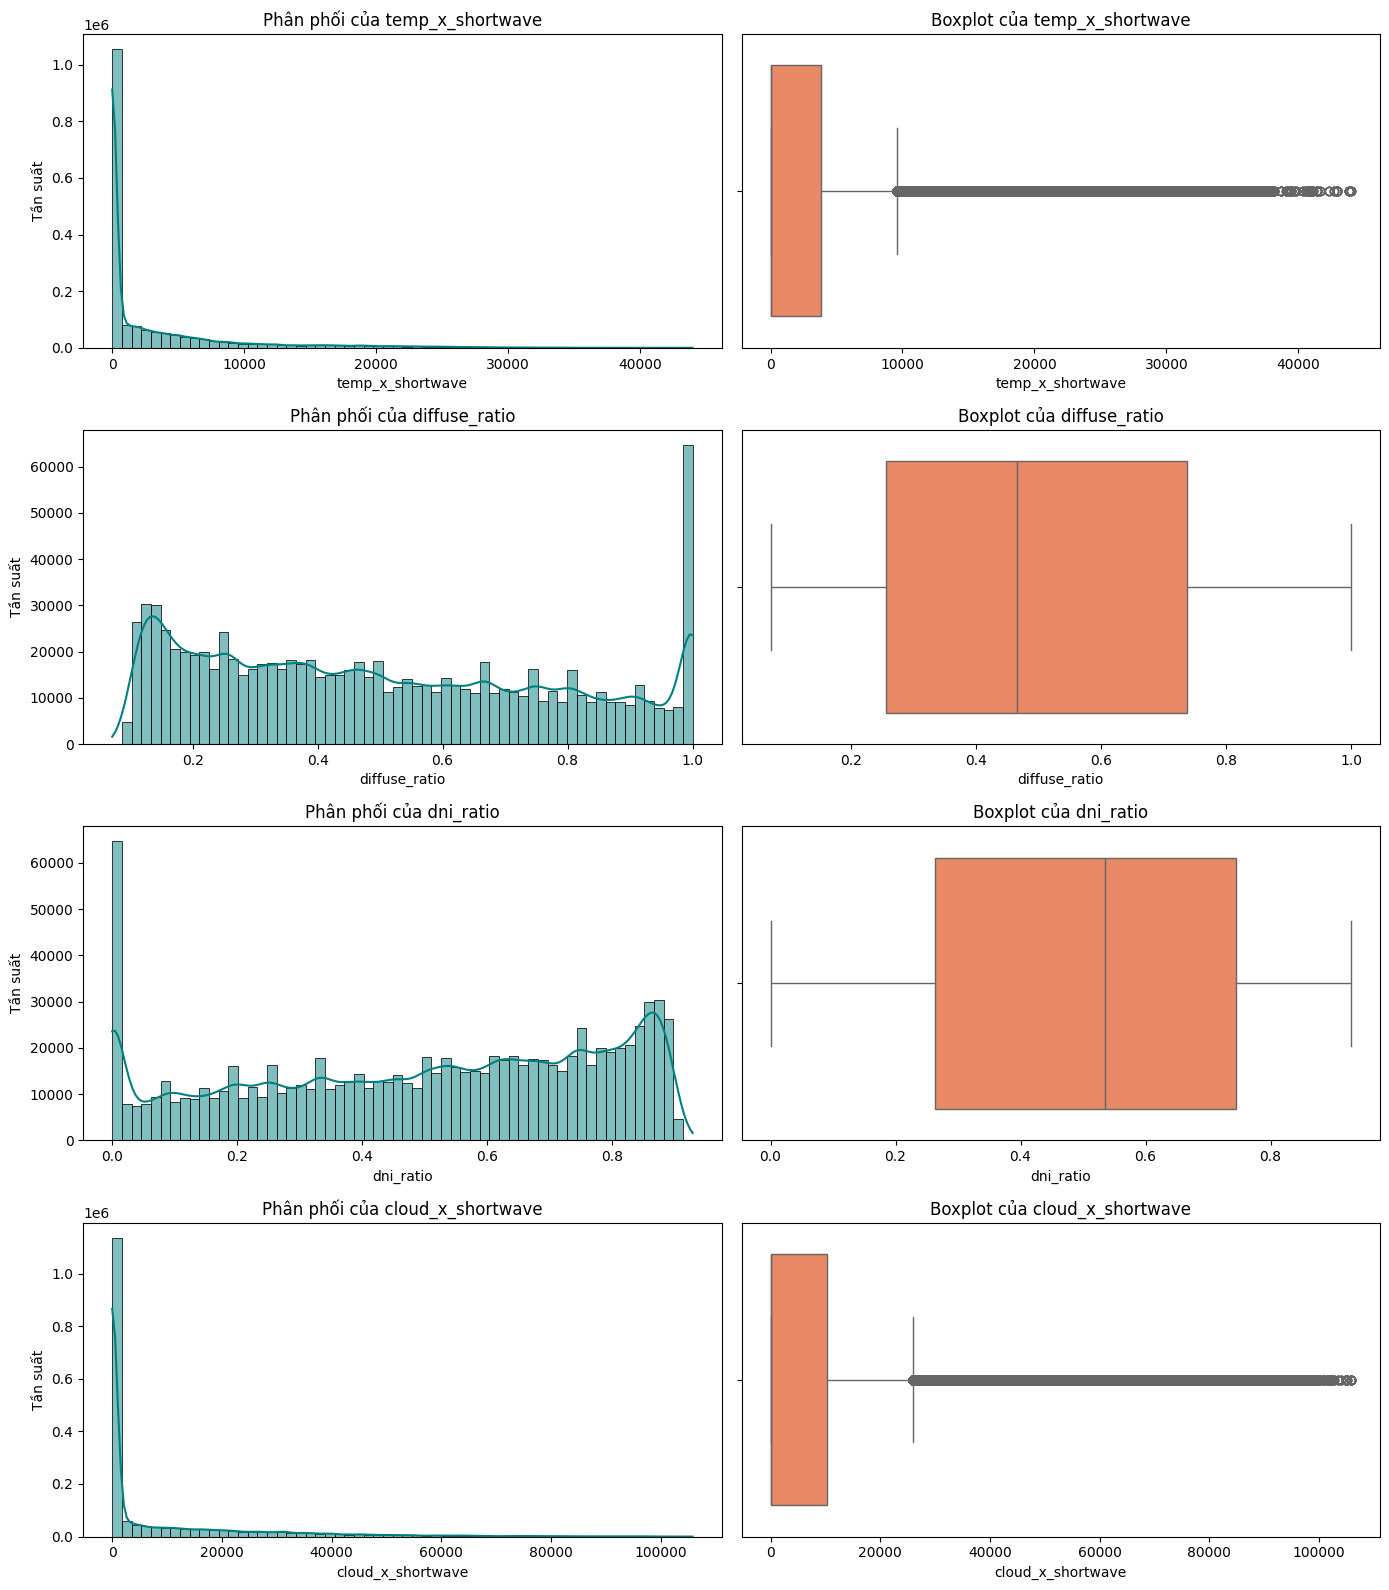

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 12.1. Vẽ Histogram và Boxplot (KDE)
fig, axes = plt.subplots(len(new_features), 2, figsize=(14, 4 * len(new_features)))

for i, col in enumerate(new_features):
    # Histogram
    sns.histplot(df_fe[col].dropna(), bins=60, kde=True, ax=axes[i, 0], color='teal', edgecolor='black')
    axes[i, 0].set_title(f'Phân phối của {col}')
    axes[i, 0].set_ylabel('Tần suất')
    
    # Boxplot để kiểm tra Outliers cục bộ
    sns.boxplot(x=df_fe[col].dropna(), ax=axes[i, 1], color='coral')
    axes[i, 1].set_title(f'Boxplot của {col}')

plt.tight_layout()
plt.show()

## Bước 13. Đánh giá Tương quan & Đa Cộng tuyến
Kiểm tra xem các features này tương quan tuyến tính (Pearson) và phi tuyến xếp hạng (Spearman) với target ra sao. Đồng thời kiểm tra đa cộng tuyến.

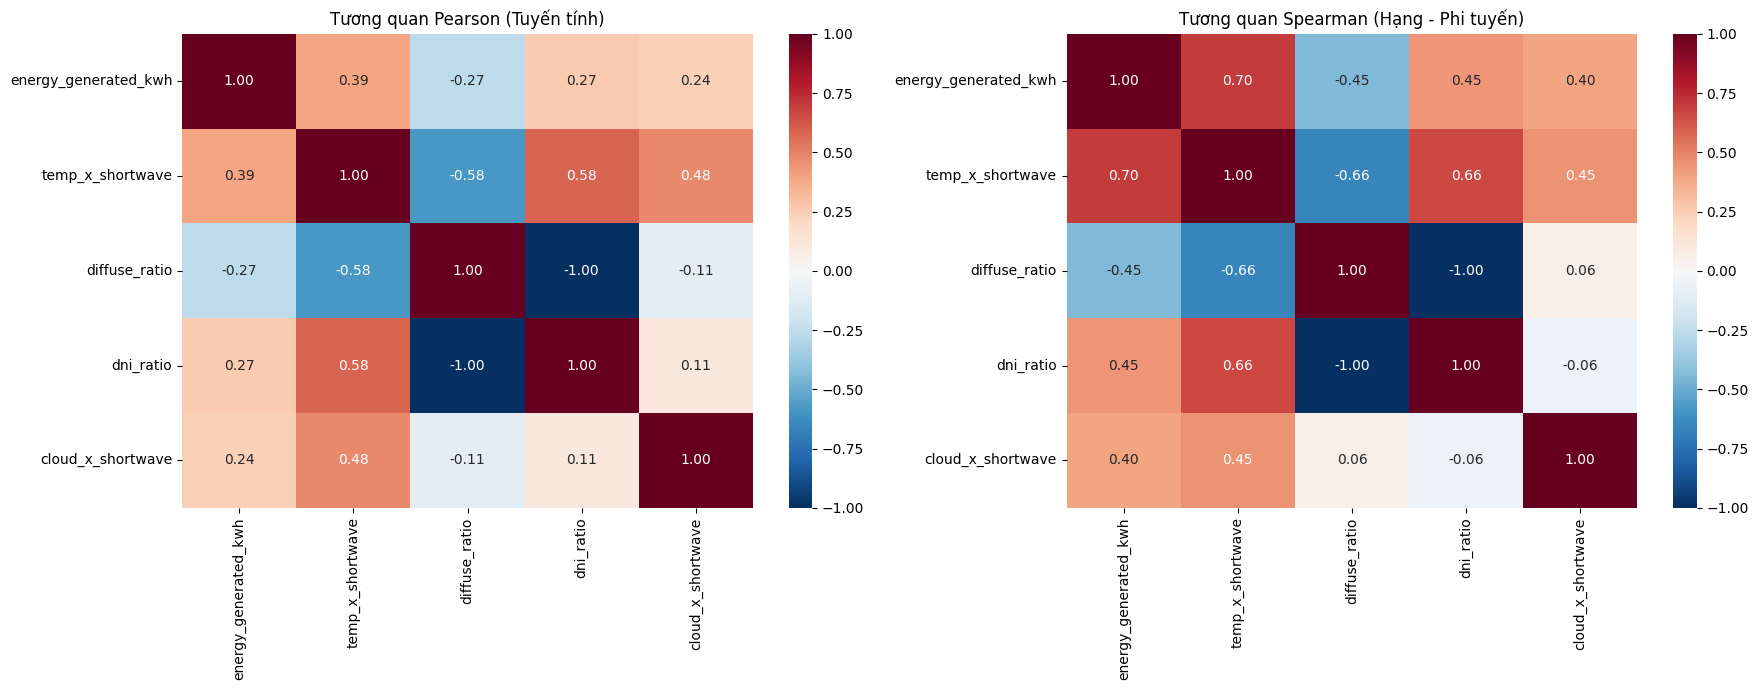

In [14]:
corr_cols = ['energy_generated_kwh'] + new_features
df_corr = df_fe[corr_cols].dropna()

pearson_corr = df_corr.corr(method='pearson')
spearman_corr = df_corr.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pearson
sns.heatmap(pearson_corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", ax=axes[0])
axes[0].set_title('Tương quan Pearson (Tuyến tính)')

# Spearman
sns.heatmap(spearman_corr, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", ax=axes[1])
axes[1].set_title('Tương quan Spearman (Hạng - Phi tuyến)')

plt.tight_layout()
plt.show()

### Nhận xét & Đề xuất về Đặc trưng:
- `temp_x_shortwave` có tương quan rất cao với `energy_generated_kwh` vì kết hợp nhiệt độ và bức xạ mặt trời (nguồn sinh năng lượng chính).
- LƯU Ý MÔ HÌNH HÓA: Đã loại bỏ hoàn toàn các đặc trưng có nguy cơ rò rỉ dữ liệu (Target Leakage) như tỷ lệ khai thác công suất trạm vì nó chứa trực tiếp biến mục tiêu.
- `diffuse_ratio`: Mang hệ số âm với sản lượng (khi ánh sáng khuếch tán chiếm tỷ trọng cao nghĩa là mây mù nhiều, dẫn đến sản lượng điện giảm).

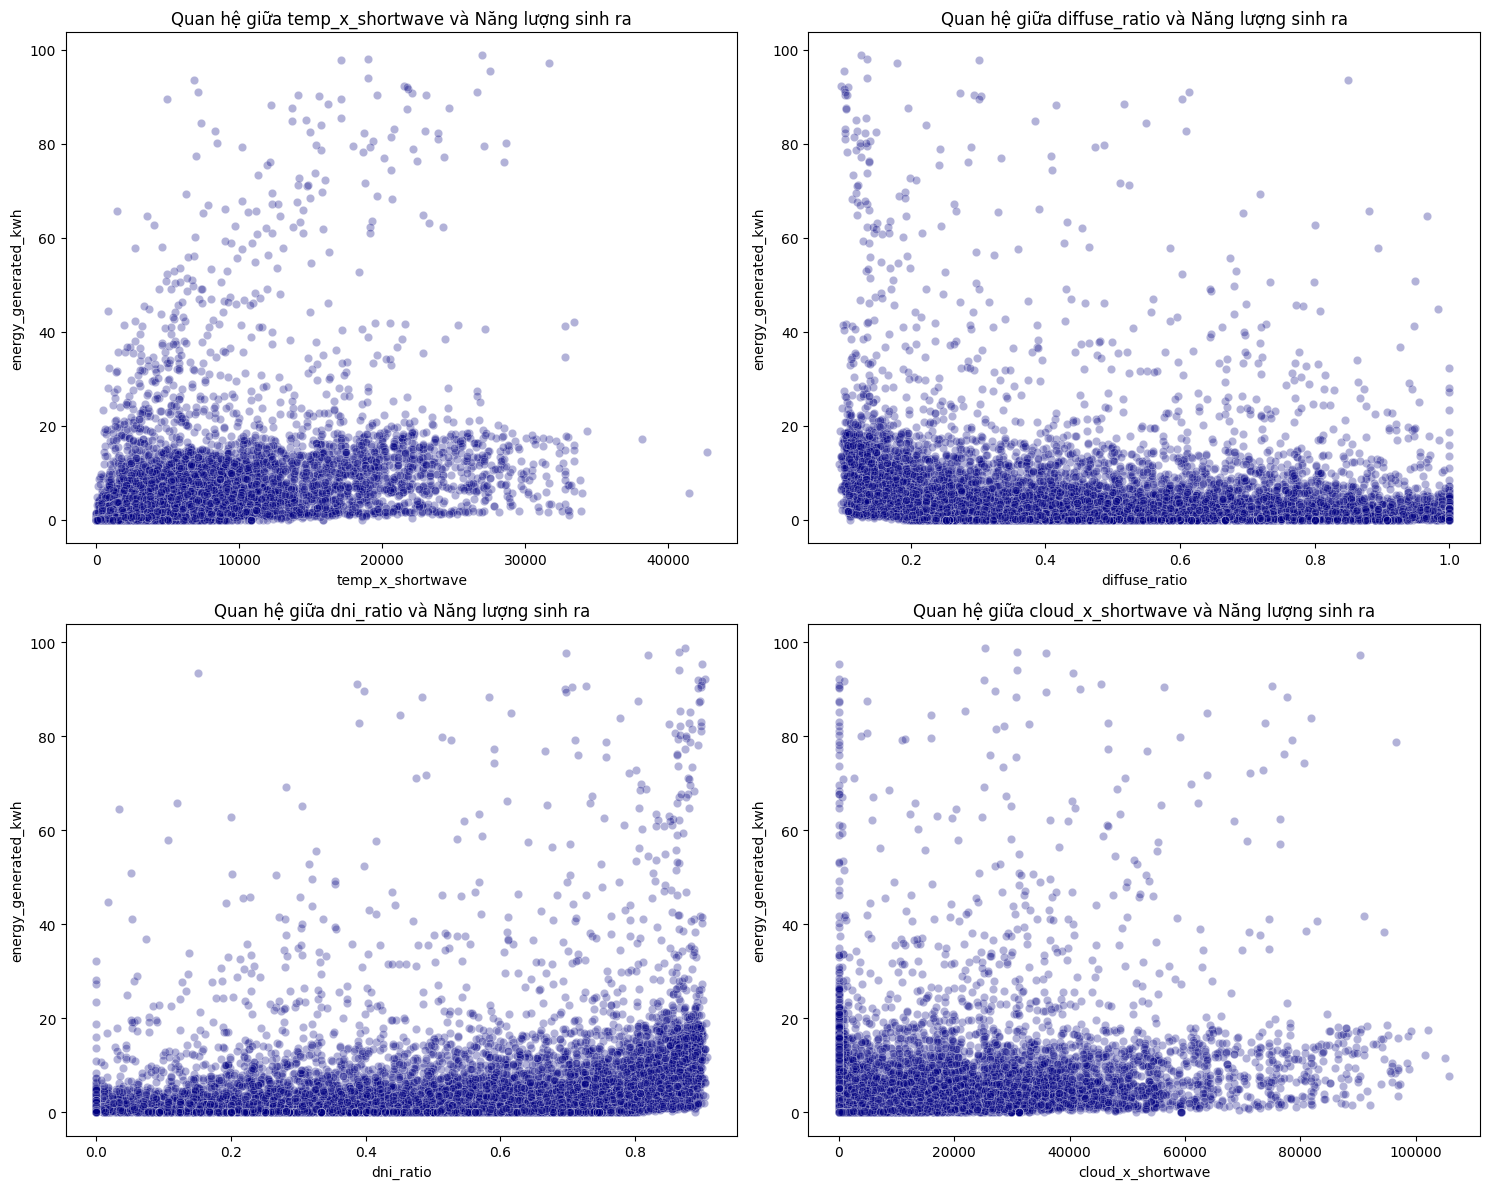

In [15]:
# 13.2. Scatter Plot Phi tuyến giữa Feature và Target (Lấy sample 10,000 điểm để tăng tốc vẽ)
sample_df = df_corr.sample(min(10000, len(df_corr)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()
features_to_plot = ['temp_x_shortwave', 'diffuse_ratio', 'dni_ratio', 'cloud_x_shortwave']

for i, col in enumerate(features_to_plot):
    sns.scatterplot(data=sample_df, x=col, y='energy_generated_kwh', alpha=0.3, ax=axes[i], color='navy')
    axes[i].set_title(f'Quan hệ giữa {col} và Năng lượng sinh ra')

plt.tight_layout()
plt.show()

## Bước 14. Bảng tổng kết và lưu bảng mã

In [16]:
feature_summary = pd.DataFrame(summary_rows)
print("--- BẢNG TỔNG KẾT TẤT CẢ TẬP DỮ LIỆU ĐÃ SINH --- ")
display(feature_summary)

maps_path = f'{OUTPUT_DIR}/{VERSION}_category_maps.json'
with open(maps_path, 'w', encoding='utf-8') as f:
    json.dump(category_maps, f, ensure_ascii=False, indent=2)

print(f"\nĐã lưu bảng mã hóa category_maps vào: {maps_path}")
print("Hoàn tất bước 03-3: Sinh đặc trưng thời tiết, mã hóa biến phân loại và kiểm định QA/QC!")

--- BẢNG TỔNG KẾT TẤT CẢ TẬP DỮ LIỆU ĐÃ SINH --- 


,name,rows,columns,feature_columns,site_count,min_timestamp,max_timestamp,complete_history_rows,incomplete_history_rows,encoded_categorical_columns,unknown_category_rows_total,lag_1_null_rows,lag_4_null_rows,rolling_mean_4_null_rows
0,development,2273970,130,55,42,2020-01-01 00:15:00,2021-12-18 09:15:00,2269938,4032,10,0,42,168,168
1,test_backward_from_development,510468,131,55,42,2021-12-18 09:30:00,2022-04-23 23:45:00,510468,0,10,0,0,0,0
2,train_alias,1791894,131,55,42,2020-01-01 00:15:00,2021-08-20 19:45:00,1787862,4032,10,0,42,168,168
3,val_alias_backward_from_train,482076,131,55,42,2021-08-20 20:00:00,2021-12-18 09:15:00,482076,0,10,0,0,0,0
4,fold_1_train,132523,132,55,13,2020-01-01 00:15:00,2020-04-29 13:45:00,131275,1248,10,0,13,52,52
5,fold_1_val_backward_from_train,289097,132,55,36,2020-04-29 14:00:00,2020-08-27 03:15:00,286889,2208,10,509746,23,92,92
6,fold_2_train,421620,132,55,36,2020-01-01 00:15:00,2020-08-27 03:15:00,418164,3456,10,0,36,144,144
7,fold_2_val_backward_from_train,417729,132,55,39,2020-08-27 03:30:00,2020-12-24 16:45:00,417441,288,10,7535,3,12,12
8,fold_3_train,839349,132,55,39,2020-01-01 00:15:00,2020-12-24 16:45:00,835605,3744,10,0,39,156,156
9,fold_3_val_backward_from_train,470469,132,55,42,2020-12-24 17:00:00,2021-04-23 06:15:00,470181,288,10,22827,3,12,12



Đã lưu bảng mã hóa category_maps vào: ../../data/model/v3/03_3_features_aggregate/v3_category_maps.json
Hoàn tất bước 03-3: Sinh đặc trưng thời tiết, mã hóa biến phân loại và kiểm định QA/QC!
